# 6-mode HighDimStokesMeasurement example

This notebook simulates a 6-output lantern measured with a 6-superpixel pupil basis. The physical forward path is:

1. apply a superpixel phase mask to a circular tophat pupil,
2. Fourier transform the pupil field to the focal plane,
3. project the focal field onto lantern input modes,
4. apply the lantern coupling matrix,
5. measure output powers.

The Stokes reconstruction recovers each output row only up to a row-wise global phase. That is expected for power-only measurements.

The final section does a backward run: specify desired output powers, choose an output phase convention, solve for superpixel coefficients, and render the pupil phase mask. The ideal complex-superpixel field and the phase-only SLM rendering are shown separately because phase-only masks cannot generally reproduce arbitrary complex coefficients exactly.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from JazLabs.simulator.HighDimStokesMeasurement import (
    build_superpixel_focal_coupling,
    coeffs_to_phase_mask,
    compare_matrices,
    generate_physical_stokes_measurements,
    make_circular_tophat,
    make_matched_focal_modes,
    make_superpixel_map,
    modal_coeffs_to_field,
    phase_mask_to_pupil_field,
    project_field_onto_modes,
    propagate_pupil_to_focal_plane,
    reconstruct_T_from_physical_stokes,
    reconstruct_T_from_stokes,
    simulate_lantern_powers_from_phase_mask,
)


def normalise_power(power):
    power = np.asarray(power, dtype=float)
    total = power.sum()
    if total == 0:
        return power
    return power / total

ImportError: cannot import name 'make_circular_tophat' from 'JazLabs.simulator.HighDimStokesMeasurement.tomography' (/Users/s4356803/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/Documents/JazLabs/src/JazLabs/simulator/HighDimStokesMeasurement/tomography.py)

In [ ]:
shape = (256, 256)
pupil = make_circular_tophat(shape, radius=112)
superpixel_map = make_superpixel_map(
    shape,
    n_superpixels_x=3,
    n_superpixels_y=2,
    pupil_mask=pupil,
)

n_superpixel_modes = int(superpixel_map.max() + 1)
n_outputs = 6
n_lantern_inputs = 6

lantern_input_modes = make_matched_focal_modes(superpixel_map, pupil)
forward_model = build_superpixel_focal_coupling(
    superpixel_map,
    pupil,
    lantern_input_modes,
)

print(f"superpixel modes: {n_superpixel_modes}")
print(f"forward model shape: {forward_model.shape}")
print(f"forward model condition: {np.linalg.cond(forward_model):.3e}")

superpixel modes: 52
forward model shape: (52, 52)
forward model condition: 2.522e+00


In [8]:
rng = np.random.default_rng(3)
T_true = (
    rng.normal(size=(n_outputs, n_lantern_inputs))
    + 1j * rng.normal(size=(n_outputs, n_lantern_inputs))
) / np.sqrt(2 * n_lantern_inputs)

physical_measurements = generate_physical_stokes_measurements(T_true, forward_model)
T_est, diagnostics = reconstruct_T_from_physical_stokes(
    physical_measurements,
    n_outputs=n_outputs,
    n_lantern_inputs=n_lantern_inputs,
)
T_commanded_est, _ = reconstruct_T_from_stokes(
    physical_measurements.stokes,
    n_outputs=n_outputs,
    n_modes=n_superpixel_modes,
)

comparison = compare_matrices(T_true, T_est)

print(f"T_true shape: {T_true.shape}")
print(f"measurements: {len(physical_measurements.stokes.input_vectors)}")
print(f"raw T relative error: {comparison.relative_error:.3e}")
print(f"raw T amplitude error: {comparison.amplitude_error:.3e}")
print(f"raw T phase RMS error: {comparison.phase_error:.3e} rad")

ValueError: T columns must match forward_model rows

In [9]:
single_mode = np.zeros(n_superpixel_modes, dtype=complex)
single_mode[0] = 1.0
binary_phase = np.ones(n_superpixel_modes, dtype=complex)
binary_phase[1::2] = -1.0

single_phase_mask = coeffs_to_phase_mask(single_mode, superpixel_map)
single_powers, single_input_coeffs, single_focal_field = simulate_lantern_powers_from_phase_mask(
    T_true,
    single_phase_mask,
    pupil,
    lantern_input_modes,
)

print("single superpixel phase-mask powers:")
print(single_powers)
print("projected lantern input amplitudes:")
print(single_input_coeffs)

fig, axes = plt.subplots(1, 4, figsize=(13, 3), constrained_layout=True)
axes[0].imshow(pupil, cmap="gray")
axes[0].set_title("Circular pupil")
axes[1].imshow(superpixel_map, cmap="tab20")
axes[1].set_title("Superpixels")
axes[2].imshow(single_phase_mask, cmap="twilight", vmin=0, vmax=2 * np.pi)
axes[2].set_title("Mode 0 phase")
axes[3].imshow(coeffs_to_phase_mask(binary_phase, superpixel_map), cmap="twilight", vmin=0, vmax=2 * np.pi)
axes[3].set_title("Binary phase")
for ax in axes:
    ax.set_axis_off()

ValueError: T columns must match number of lantern input modes

## Backward run: target lantern powers to pupil phase

Output powers alone do not specify output phases. Here the target output amplitudes are built from the desired powers with zero output phase. Any other chosen output phase vector would be another valid design target with the same powers.

The solve is done with the reconstructed commanded-basis matrix. It gives complex superpixel coefficients. The phase-only mask below is the SLM-compatible phase rendering of those coefficients.

In [5]:
desired_powers = np.array([1.0, 0.55, 0.25, 0.12, 0.06, 0.02])
desired_powers = normalise_power(desired_powers)
desired_output_phases = np.zeros(n_outputs)
desired_output_amplitudes = np.sqrt(desired_powers) * np.exp(1j * desired_output_phases)

# Use the Stokes-reconstructed commanded-basis matrix, as you would after measurement.
# Its row-wise phase gauge is arbitrary, but that does not change output powers.
backward_coeffs = np.linalg.pinv(T_commanded_est) @ desired_output_amplitudes

# Ideal complex-superpixel check through the actual physical chain.
ideal_pupil_field = modal_coeffs_to_field(backward_coeffs, superpixel_map, pupil)
ideal_focal_field = propagate_pupil_to_focal_plane(ideal_pupil_field)
ideal_lantern_input = project_field_onto_modes(ideal_focal_field, lantern_input_modes)
ideal_output = T_true @ ideal_lantern_input
ideal_powers = normalise_power(np.abs(ideal_output) ** 2)

# Phase-only SLM rendering. This keeps only the phase of each superpixel coefficient.
backward_phase_mask = coeffs_to_phase_mask(backward_coeffs, superpixel_map)
phase_only_powers, phase_only_input, phase_only_focal_field = simulate_lantern_powers_from_phase_mask(
    T_true,
    backward_phase_mask,
    pupil,
    lantern_input_modes,
)
phase_only_powers = normalise_power(phase_only_powers)

print("output | target | ideal complex superpixel | phase-only mask")
for idx, (target, ideal, phase_only) in enumerate(
    zip(desired_powers, ideal_powers, phase_only_powers)
):
    print(f"{idx:>6d} | {target:>6.3f} | {ideal:>24.3f} | {phase_only:>15.3f}")

print(f"complex coefficient norm: {np.linalg.norm(backward_coeffs):.3e}")

output | target | ideal complex superpixel | phase-only mask
     0 |  0.500 |                    0.500 |           0.155
     1 |  0.275 |                    0.275 |           0.039
     2 |  0.125 |                    0.125 |           0.002
     3 |  0.060 |                    0.060 |           0.192
     4 |  0.030 |                    0.030 |           0.181
     5 |  0.010 |                    0.010 |           0.431
complex coefficient norm: 3.880e-02


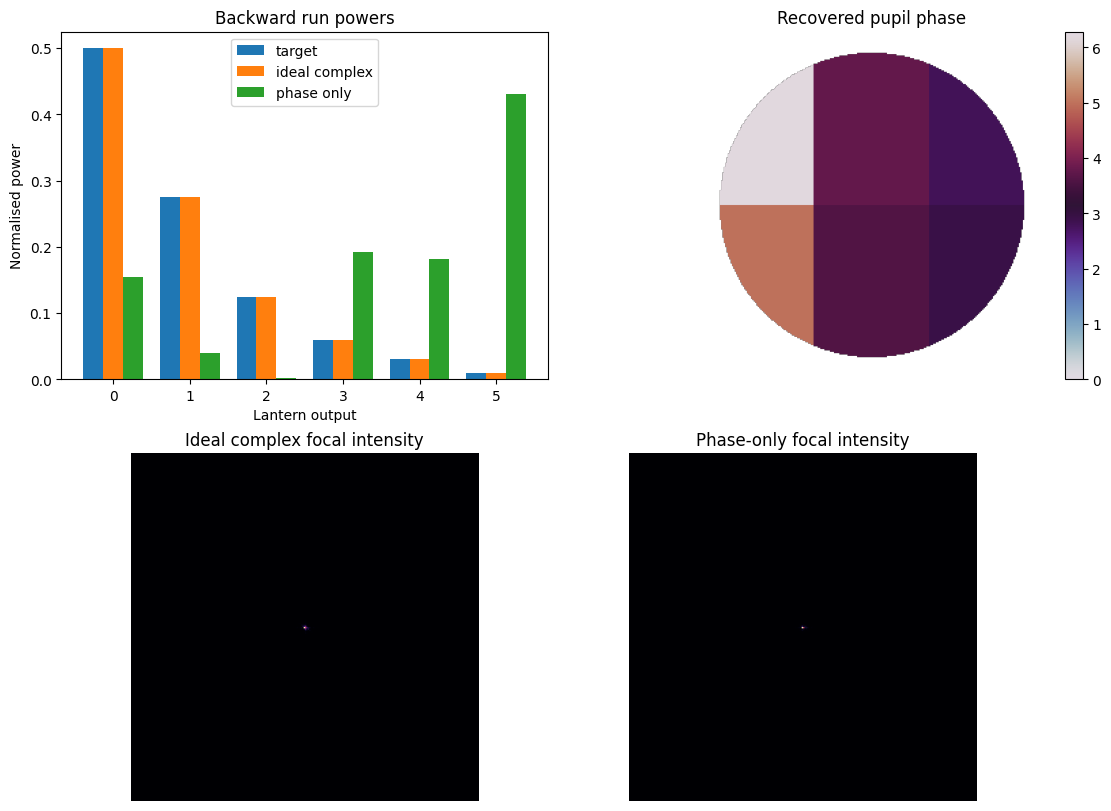

In [6]:
x = np.arange(n_outputs)
width = 0.26

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].bar(x - width, desired_powers, width, label="target")
axes[0, 0].bar(x, ideal_powers, width, label="ideal complex")
axes[0, 0].bar(x + width, phase_only_powers, width, label="phase only")
axes[0, 0].set_xlabel("Lantern output")
axes[0, 0].set_ylabel("Normalised power")
axes[0, 0].set_title("Backward run powers")
axes[0, 0].legend()

masked_phase = np.ma.masked_where(pupil <= 0, backward_phase_mask)
phase_image = axes[0, 1].imshow(masked_phase, cmap="twilight", vmin=0, vmax=2 * np.pi)
axes[0, 1].set_title("Recovered pupil phase")
axes[0, 1].set_axis_off()
fig.colorbar(phase_image, ax=axes[0, 1], fraction=0.046, pad=0.04)

axes[1, 0].imshow(np.abs(ideal_focal_field) ** 2, cmap="magma")
axes[1, 0].set_title("Ideal complex focal intensity")
axes[1, 0].set_axis_off()

axes[1, 1].imshow(np.abs(phase_only_focal_field) ** 2, cmap="magma")
axes[1, 1].set_title("Phase-only focal intensity")
axes[1, 1].set_axis_off()